# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Rachmitha Salma
- **Email:** sallmarachmitha@gmail.com
- **ID Dicoding:** CDCC183D6X2022

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca terhadap jumlah peminjaman sepeda per hari pada Bike Sharing Dataset selama periode 2022-2012?
- **Pertanyaan 2:** Kapan waktu (berdasarkan jam dan jenis hari: hari kerja vs akhir pekan) dengan jumlah peminjaman sepeda tertinggi pada periode 2011-2012?


## Import Semua Packages/Library yang Digunakan

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [36]:
day_df = pd.read_csv('/content/sample_data/day.csv')
hour_df = pd.read_csv('/content/sample_data/hour.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [37]:
# cek struktur data
day_df.info()
day_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [38]:
hour_df.info()
hour_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:** (Opsional)
- Dataset terdiri dari data peminjaman sepeda (day_df) dan per jam (hour_df).
- Terdapat berbagai variabel seperti kondisi cuaca, suhu, kelembapan, serta tipe pengguna (casual dan regidtered).
- Tidak semua kolom memiliki tipe data yang sesuai (misalnya tanggal masih dalam bentuk string)
- Dataset memiliki potensi untuk dianalisis berdasarkan waktu dan kondisi lingkungan.

### Assessing Data

#### Identifying ... problem

Indentifikasi masalah:
- Tipe data tidak sesuai, kolom dteday masih bertipe object (string), seharusnya datetime.
- Kategori masih dalam bentuk angka, kolom seperti season, weathersit, dan weekday masih berupa angka sehingga sulit dipahami.
- Tidak ditemukan missing value dan duplicate pada dataset.

In [39]:
# cek missing values data day.csv
day_df.isnull().sum()

# cek duplicate data day.csv
day_df.duplicated().sum()

#cek tipe data pada data day.csv
day_df.info()

#cek nilai unik pada data day.csv
day_df['season'].unique()
day_df['weathersit'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


array([2, 1, 3])

In [40]:
# cek missing values data hour.csv
hour_df.isnull().sum()

# cek duplicate data hour.csv
hour_df.duplicated().sum()

# cek tipe data pada data hour.csv
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**Steps to Take:**
- Mengubah tipe data kolom dteday menjadi datetime.
- Mengubah nilai kategori menjadi label yang lebih deskriptif (misalnya season dan weather).
- Memastikan tidak ada missing value atau data duplikat.

**Insight:** (Opsional)
- Dataset secara umum memiliki kualitas yang baik karena tidak ditemukan missing value maupun data duplikat.
- Beberapa kolom masih perlu preprocessing agar lebih mudah dianalisis, terutama dalam hal tipe data dan representasi kategori.
- Data sudah cukup siap untuk masuk ke tahap cleaning dan analisis lebih lanjut.

### Cleaning Data

#### Fixing ... problem

In [41]:
# mengubah tipe data kolom dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [42]:
# mapping kategori season
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

# mapping kategori weather
weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
}

# terapkan mapping
day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)

hour_df['season'] = hour_df['season'].map(season_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)

# cek hasil perubahan
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,6,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Kolom dteday telah berhasil diubah menjadi format datetime sehingga memudahkan anailsis berbasis waktu.
- Nilai kategori pada kolom seperti season dan weathersit telah diubah menjadi label yang lebih deskriptif sehingga lebih mudah dipahami.
- Dataset tidak memiliki missing value maupun data duplikat sehingga tidak diperlukan proses pembersihan tambahan.
- Data telah siap untuk digunakan pada tahap Exploratory Data Analysis (EDA).

## Exploratory Data Analysis (EDA)

### Explore ...

Analisis Pengaruh Cuaca

In [43]:
# hubungan suhu dengan jumlah peminjaman
day_df[['temp', 'cnt']].corr()

# rata-rata peminjaman berdasarkan kondisi cuaca
day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False)

,cnt
weathersit,
Clear,4876.786177
Mist,4035.862348
Light Snow/Rain,1803.285714


Aanalisis berdasarkan musim

In [44]:
day_df.groupby('season')['cnt'].mean().sort_values(ascending=False)

,cnt
season,
Fall,5644.303191
Summer,4992.331522
Winter,4728.162921
Spring,2604.132597


Analisis pola jam

In [45]:
hour_df.groupby('hr')['cnt'].mean()

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


weekday vs weekend

In [46]:
hour_df.groupby('workingday')['cnt'].mean()

,cnt
workingday,
0,181.405332
1,193.207754


Korelasi Antar Variabel

In [47]:
day_df[['temp','hum','windspeed','cnt']].corr()

,temp,hum,windspeed,cnt
temp,1.000000,0.126963,-0.157944,0.627494
hum,0.126963,1.000000,-0.248489,-0.100659
windspeed,-0.157944,-0.248489,1.000000,-0.234545
cnt,0.627494,-0.100659,-0.234545,1.000000


**Insight:** (Opsional)
- Terdapat hubungan positif antara suhu dan jumlah peminjaman sepeda, di mana peningkatan suhu cenderung diikuti dengan meningkatnya jumlah pengguna.
- ondisi cuaca yang cerah (Clear) memiliki rata-rata peminjaman tertinggi dibandingkan kondisi cuaca lainnya.
- Penggunaan sepeda cenderung lebih tinggi pada musim tertentu seperti Fall dan Summer dibandingkan Winter.
- Pola penggunaan sepeda menunjukkan adanya jam sibuk, terutama pada pagi dan sore hari yang mengindikasikan penggunaan untuk aktivitas commuting.
- Rata-rata peminjaman pada hari kerja lebih tinggi dibandingkan akhir pekan, menunjukkan dominasi penggunaan oleh pekerja atau pengguna rutin.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

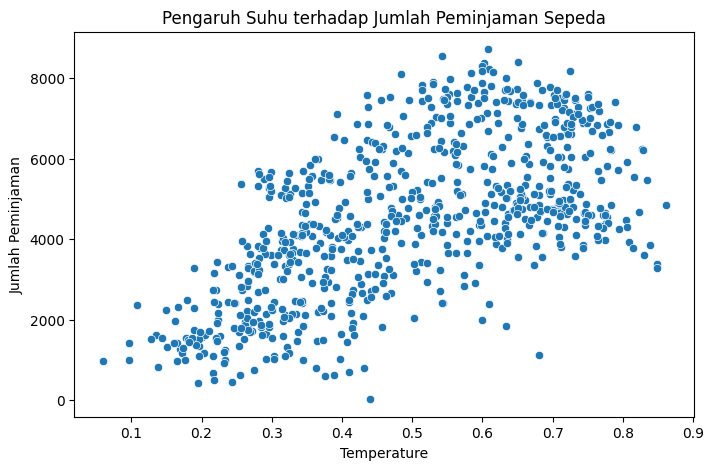

In [48]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='temp', y='cnt', data=day_df)
plt.title('Pengaruh Suhu terhadap Jumlah Peminjaman Sepeda')
plt.xlabel('Temperature')
plt.ylabel('Jumlah Peminjaman')
plt.show()

- Terdapat hubungan positif antara suhu dan jumlah peminjaman sepeda, di mana semakin tinggi suhu maka jumlah peminjaman cenderung meningkat.
- Kondisi cuaca cerah (Clear) memiliki jumlah peminjaman tertinggi dibandingkan kondisi cuaca lainnya.
- Pada kondisi cuaca buruk seperti hujan atau salju, jumlah peminjaman mengalami penurunan signifikan.

### Pertanyaan 2:

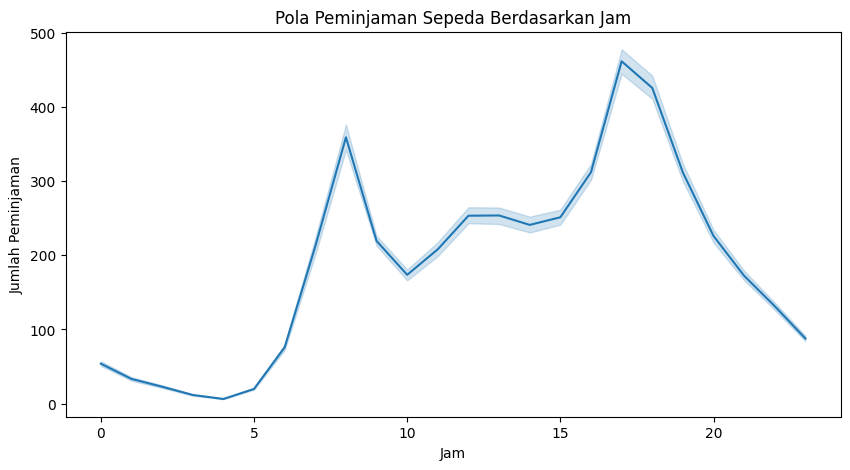

In [49]:
plt.figure(figsize=(10,5))
sns.lineplot(x='hr', y='cnt', data=hour_df)
plt.title('Pola Peminjaman Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Peminjaman')
plt.show()

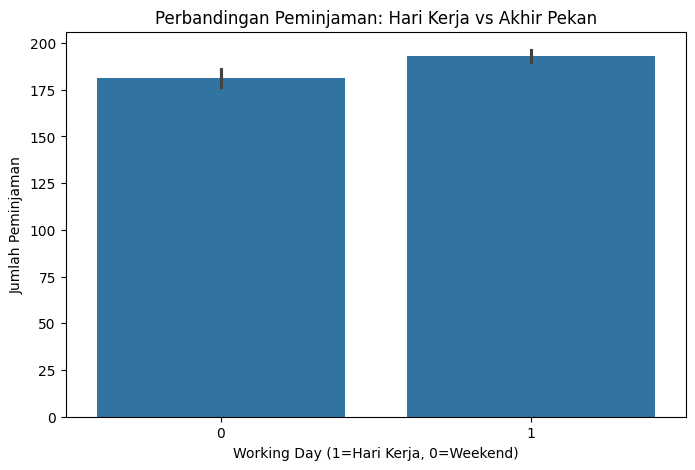

In [50]:
plt.figure(figsize=(8,5))
sns.barplot(x='workingday', y='cnt', data=hour_df)
plt.title('Perbandingan Peminjaman: Hari Kerja vs Akhir Pekan')
plt.xlabel('Working Day (1=Hari Kerja, 0=Weekend)')
plt.ylabel('Jumlah Peminjaman')
plt.show()

- Terdapat dua puncak penggunaan sepeda, yaitu pada pagi hari (sekitar jam 07–09) dan sore hari (sekitar jam 17–19).
- Pola ini menunjukkan bahwa sepeda banyak digunakan untuk aktivitas commuting seperti berangkat dan pulang kerja.
- Rata-rata peminjaman pada hari kerja lebih tinggi dibandingkan akhir pekan, yang menunjukkan dominasi pengguna rutin (registered users).

**Insight:** (Opsional)
- Faktor cuaca dan waktu memiliki pengaruh signifikan terhadap jumlah peminjaman sepeda.
- Pola penggunaan menunjukkan adanya perilaku rutin pengguna, terutama pada jam sibuk.
- Informasi ini dapat digunakan untuk meningkatkan efisiensi operasional layanan bike sharing.

## Analisis Lanjutan (Opsional)

Analisis Perbandingan Casual vs Registered

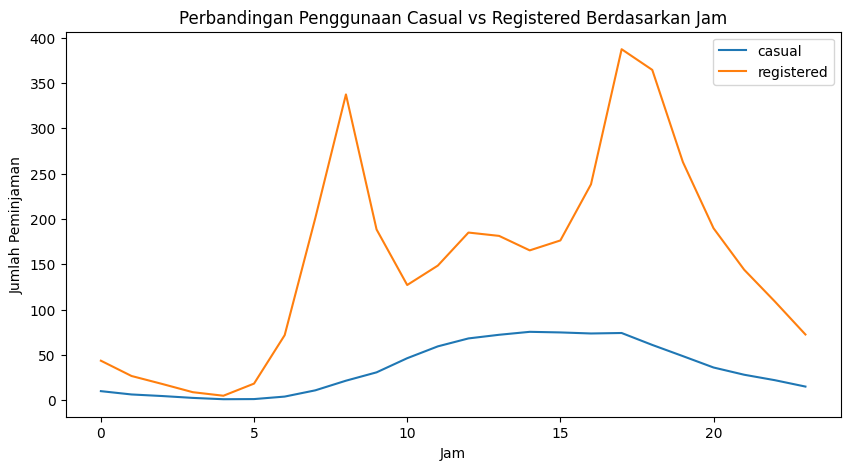

In [51]:
hour_df.groupby('hr')[['casual', 'registered']].mean().plot(figsize=(10,5))
plt.title('Perbandingan Penggunaan Casual vs Registered Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Peminjaman')
plt.show()

**Insight:**
- Pengguna registered mendominasi penggunaan pada jam sibuk (pagi dan sore), yang mengindikasikan penggunaan untuk aktivitas kerja.
- Pengguna casual lebih aktif pada siang hari, yang cenderung berkaitan dengan aktivitas rekreasi.
- Pola ini menunjukkan adanya perbedaan perilaku antara kedua tipe pengguna.
- Perbedaan pola ini menunjukkan adanya segmentasi pengguna berdasarkan tujuan penggunaan, yaitu commuting (registered) dan rekreasi (casual).

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**
    - Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah peminjaman sepeda.
    - Suhu yang lebih tinggi cenderung meningkatkan jumlah peminjaman sepeda.
    - Cuaca cerah (Clear) menghasilkan jumlah peminjaman tertinggi, sedangkan kondisi cuaca buruk seperti hujan atau salju menyebabkan penurunan jumlah pengguna secara signifikan.

- **Conclusion pertanyaan 2:**

   - Pola penggunaan sepeda menunjukkan dua puncak utama, yaitu pada pagi hari (07-09) dan sore hari (17-19).
   - Hal ini menunjukkan bahwa sepeda banyak digunakan untuk aktivitas commuting seperti berangkat dan pulang kerja.
   - Penggunaan pada hari kerja lebih tinggi dibandingkan akhir pekan, yang mengindikasikan dominasi pengguna rutin (registered users).

**Rekomendasi Action Item:**
- Menyediakan lebih banyak sepeda pada jam sibuk (pagi dan sore hari) untuk mengantisipasi tingginya permintaan.
- Mengoptimalkan distribusi sepeda pada hari kerja dibandingkan akhir pekan.
- Menyesuaikan jumlah sepeda yang tersedia berdasarkan kondisi cuaca, terutama mengurangi operasional saat cuaca buruk.
- Mengembangkan strategi promosi untuk meningkatkan penggunaan sepeda pada kondisi cuaca kurang ideal.


In [53]:
#menyimpan data yang sudah diolah
day_df.to_csv('main_data.csv', index=False)